In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sudithholla/house-price/data.csv


In [2]:
house_data=pd.read_csv('/kaggle/input/datasets/sudithholla/house-price/data.csv',index_col='date',parse_dates=True)

In [3]:
house_data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
date,,,,,,,,,,,,,,,,,
2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
house_data.shape

(4600, 17)

In [30]:
sqft_mean=house_data.groupby('sqft_living').price.mean()


In [32]:
for index,row in house_data.iterrows():
    if row['price']==0:
        row['price']=sqft_mean[row['sqft_living']]
        

In [33]:
house_data.shape

(4600, 17)

In [34]:
house_data.price.isna().sum()

np.int64(0)

In [35]:
house_data.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'],
      dtype='object')

In [37]:
house_data.groupby('bedrooms').apply(lambda df:df['price'])

/tmp/ipykernel_58/728079685.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  house_data.groupby('bedrooms').apply(lambda df:df['price'])


bedrooms  date      
0.0       2014-06-12    1095000.0
          2014-06-24    1295648.0
1.0       2014-05-07     250000.0
          2014-05-12     235000.0
          2014-05-16     350000.0
                          ...    
7.0       2014-06-25     280000.0
          2014-07-09     599000.0
8.0       2014-05-28    1970000.0
          2014-07-03     340000.0
9.0       2014-05-07     599999.0
Name: price, Length: 4600, dtype: float64

In [38]:
house_data.groupby(['city','bedrooms']).apply(lambda df:df.price.agg([min,max]))

/tmp/ipykernel_58/1213578360.py:1: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  house_data.groupby(['city','bedrooms']).apply(lambda df:df.price.agg([min,max]))
/tmp/ipykernel_58/1213578360.py:1: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  house_data.groupby(['city','bedrooms']).apply(lambda df:df.price.agg([min,max]))
/tmp/ipykernel_58/1213578360.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the gro

price                        min        max
city         bedrooms                      
Algona       2.0        100000.0   100000.0
             3.0        196440.0   230000.0
             4.0        248000.0   262000.0
Auburn       1.0        115000.0   115000.0
             2.0         87500.0   475000.0
...                          ...        ...
Woodinville  5.0             0.0   950000.0
             6.0       1135000.0  1135000.0
Yarrow Point 3.0        899000.0  1901000.0
             4.0         84350.0    84350.0
             5.0       1895000.0  1895000.0

[190 rows x 2 columns]

In [39]:
house_data.groupby('condition').apply(lambda df:df.price.agg([min,max]))

/tmp/ipykernel_58/3849225787.py:1: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  house_data.groupby('condition').apply(lambda df:df.price.agg([min,max]))
/tmp/ipykernel_58/3849225787.py:1: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  house_data.groupby('condition').apply(lambda df:df.price.agg([min,max]))
/tmp/ipykernel_58/3849225787.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns af

price,min,max
condition,,
1,7800.0,550000.0
2,0.0,2555000.0
3,0.0,12899000.0
4,0.0,26590000.0
5,0.0,3200000.0


In [40]:
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

<Axes: xlabel='sqft_living', ylabel='price'>

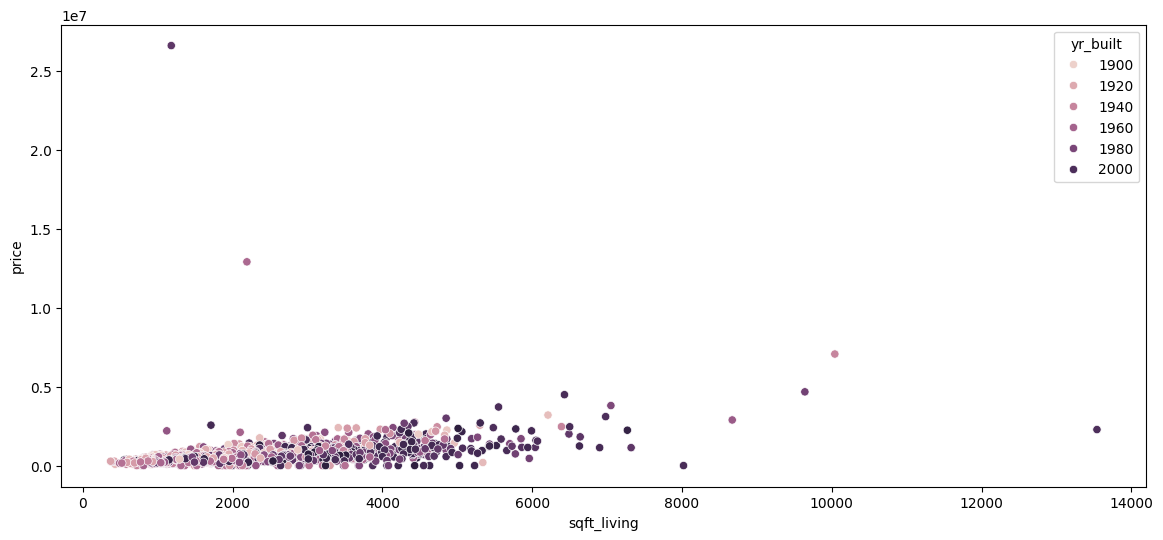

In [41]:
plt.figure(figsize=(14,6))
sns.scatterplot(x=house_data.sqft_living,y=house_data.price,hue=house_data['yr_built'])

In [15]:
sns.histplot(data=house_data.bedrooms,hue=house_data['country'])

ValueError: The following variable cannot be assigned with wide-form data: `hue`

In [16]:
house_data.groupby('waterfront')['price'].mean()

waterfront
0    5.510122e+05
1    1.596783e+06
Name: price, dtype: float64

In [22]:
reno_house_price=house_data[house_data.yr_renovated>0].price.mean()
print(reno_house_price)

538212.4420044597


In [23]:
nonreno_house_price=house_data[house_data.yr_renovated<=0].price.mean()
print(nonreno_house_price)

571333.2562744113


In [30]:
top10_cities=house_data.groupby('city')['price'].mean().sort_values(ascending=False)[0:10]

<Axes: xlabel='city', ylabel='price'>

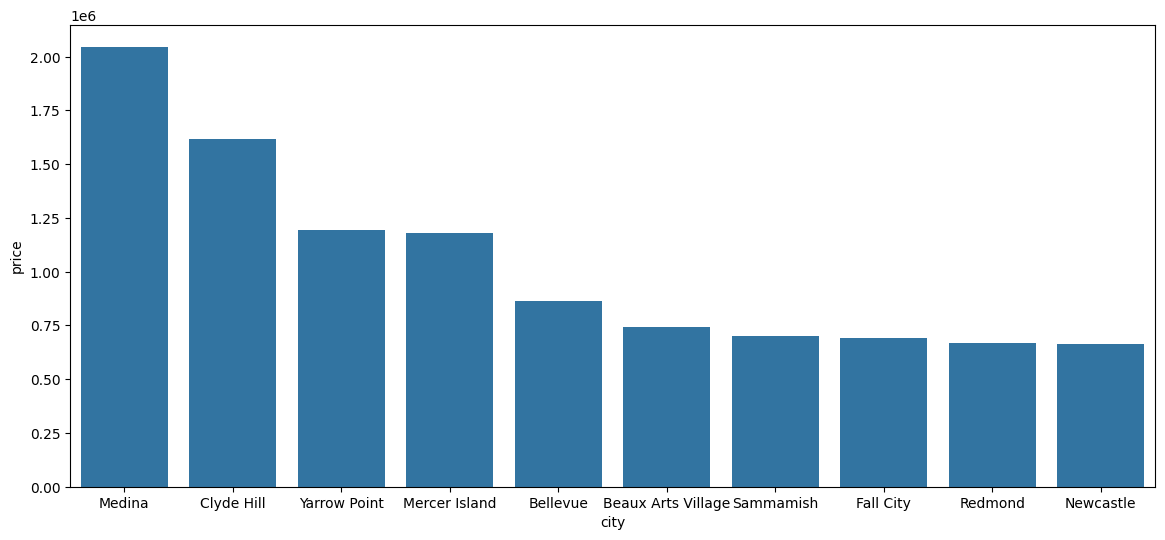

In [33]:
plt.figure(figsize=(14,6))
sns.barplot(data=top10_cities)